<a href="https://colab.research.google.com/github/klarinkintany-ui/IDS_PA2_W7_S11_Klarin-kintany/blob/main/IDS_PA2_W7_S11_Klarin_Kintany_2902785173.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


## Dataset: Quebec Housing Sales

**Tugas Personal ke-2 Week 7 S11**
**Topik:** Exploratory Data Analysis (EDA) dan Visualisasi Data



In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

df = pd.read_csv("quebec_housing_sales_v2.csv")
print("Ukuran dataset:", df.shape)
df.info()

Ukuran dataset: (5000, 14)
<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   property_id       5000 non-null   int64  
 1   city              5000 non-null   str    
 2   neighborhood      5000 non-null   str    
 3   property_type     5000 non-null   str    
 4   bedrooms          5000 non-null   int64  
 5   bathrooms         5000 non-null   int64  
 6   living_area_sqft  5000 non-null   int64  
 7   lot_size_sqft     3789 non-null   float64
 8   year_built        5000 non-null   int64  
 9   renovation_year   1592 non-null   float64
 10  garage            5000 non-null   str    
 11  basement          5000 non-null   str    
 12  sale_year         5000 non-null   int64  
 13  sale_price        5000 non-null   int64  
dtypes: float64(2), int64(7), str(5)
memory usage: 547.0 KB


## Menampilkan 5 Baris Pertama Dataset

In [ ]:
df.head()

,property_id,city,neighborhood,property_type,bedrooms,bathrooms,living_area_sqft,lot_size_sqft,year_built,renovation_year,garage,basement,sale_year,sale_price
0,1,Châteauguay,Centre-Ville,Townhouse,3,2,1160,2304.0,2022,NaN,Yes,No,2024,326000
1,2,Trois-Rivières,Cap-de-la-Madeleine,Duplex,4,4,1807,5869.0,2006,2024.0,No,Yes,2025,444000
2,3,Lévis,Charny,Townhouse,3,1,803,3387.0,1989,NaN,Yes,Yes,2025,273000
3,4,Laval,Fabreville,Single Family,3,3,1083,11417.0,1972,2016.0,Yes,Yes,2023,465000
4,5,Longueuil,Greenfield Park,Condo,2,2,714,NaN,1997,2010.0,Yes,No,2022,371000


## Jumlah Missing Values per Kolom

In [ ]:
missing = df.isna().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_summary = pd.DataFrame({"missing_count": missing, "missing_pct(%)": missing_pct})
missing_summary[missing_summary["missing_count"] > 0]

,missing_count,missing_pct(%)
lot_size_sqft,1211,24.22
renovation_year,3408,68.16


## Statistik Deskriptif Dasar

In [ ]:
num_cols = ["bedrooms", "bathrooms", "living_area_sqft", "lot_size_sqft",
            "year_built", "sale_price"]

desc_stats = df[num_cols].agg(["mean", "median", "std", "skew", "kurt"]).T
desc_stats.columns = ["Mean", "Median", "Std Dev", "Skewness", "Kurtosis"]
desc_stats

,Mean,Median,Std Dev,Skewness,Kurtosis
bedrooms,3.488200,3.0,1.357435,0.443272,-0.154855
bathrooms,2.325800,2.0,0.968009,0.667978,0.659093
living_area_sqft,1313.693800,1273.0,472.106052,0.450176,-0.285009
lot_size_sqft,6257.154658,5767.0,2811.434500,0.683406,-0.194550
year_built,1983.074000,1985.0,26.483028,-0.707988,0.366143
sale_price,480214.000000,453000.0,177125.385206,0.978991,1.635350


In [ ]:
df[num_cols].describe()

,bedrooms,bathrooms,living_area_sqft,lot_size_sqft,year_built,sale_price
count,5000.000000,5000.000000,5000.000000,3789.000000,5000.000000,5.000000e+03
mean,3.488200,2.325800,1313.693800,6257.154658,1983.074000,4.802140e+05
std,1.357435,0.968009,472.106052,2811.434500,26.483028,1.771254e+05
min,1.000000,1.000000,469.000000,1570.000000,1900.000000,1.140000e+05
25%,2.000000,2.000000,915.000000,4086.000000,1966.000000,3.527500e+05
50%,3.000000,2.000000,1273.000000,5767.000000,1985.000000,4.530000e+05
75%,4.000000,3.000000,1650.000000,8005.000000,2004.000000,5.840000e+05
max,8.000000,6.000000,2967.000000,14834.000000,2023.000000,1.425000e+06


**Interpretasi awal:**
- `sale_price` memiliki skewness ≈ 0.98 (right-skewed), artinya sebagian besar rumah terjual pada harga menengah, namun ada sejumlah kecil properti dengan harga jual sangat tinggi yang menarik ekor distribusi ke kanan.
- `year_built` memiliki skewness negatif (≈ -0.71), menunjukkan lebih banyak rumah tua dibanding rumah yang sangat baru.
- Kurtosis `sale_price` (≈ 1.64) menunjukkan distribusi yang lebih "runcing" (leptokurtic) dibanding distribusi normal, mengindikasikan adanya outlier harga tinggi.

## Visualisasi Data

## 1. Histogram — Distribusi Harga Jual (sale_price)

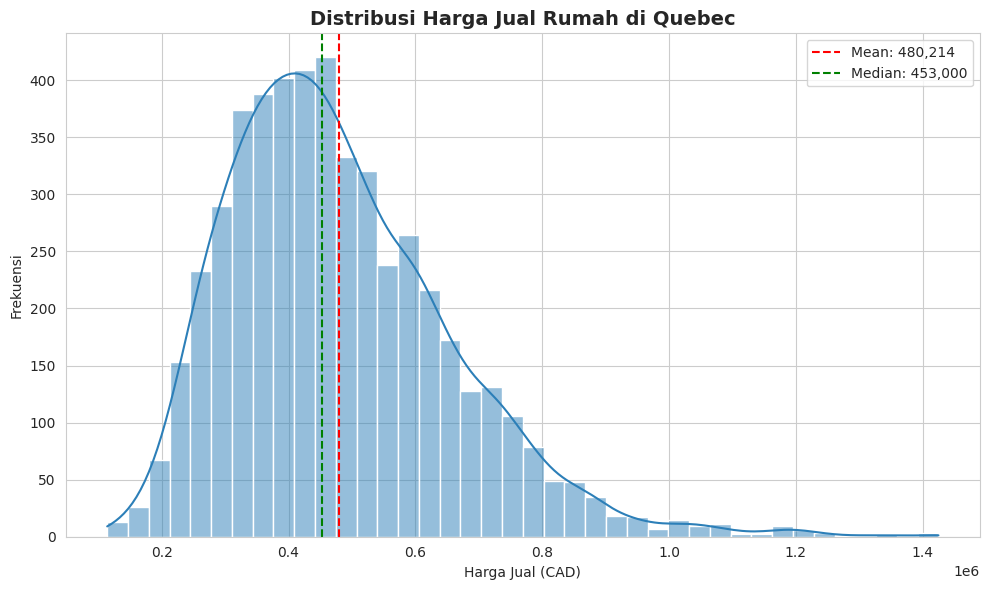

In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(df["sale_price"], bins=40, kde=True, color="#2c7fb8")
plt.title("Distribusi Harga Jual Rumah di Quebec", fontsize=14, fontweight="bold")
plt.xlabel("Harga Jual (CAD)")
plt.ylabel("Frekuensi")
plt.axvline(df["sale_price"].mean(), color="red", linestyle="--", label=f'Mean: {df["sale_price"].mean():,.0f}')
plt.axvline(df["sale_price"].median(), color="green", linestyle="--", label=f'Median: {df["sale_price"].median():,.0f}')
plt.legend()
plt.tight_layout()
plt.savefig("hist_sale_price.png", dpi=150)
plt.show()

### 2. Boxplot — Deteksi Outlier Harga Jual berdasarkan Tipe Properti

/tmp/ipykernel_594/1411517135.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="property_type", y="sale_price", order=order, palette="Set2")


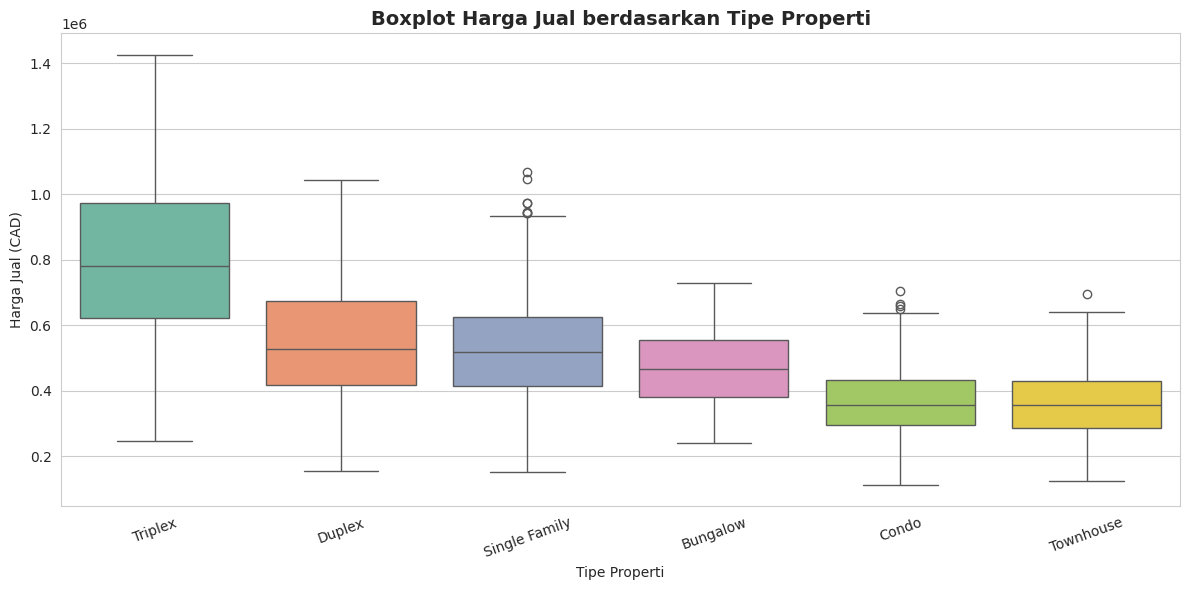

In [ ]:
plt.figure(figsize=(12, 6))
order = df.groupby("property_type")["sale_price"].median().sort_values(ascending=False).index
sns.boxplot(data=df, x="property_type", y="sale_price", order=order, palette="Set2")
plt.title("Boxplot Harga Jual berdasarkan Tipe Properti", fontsize=14, fontweight="bold")
plt.xlabel("Tipe Properti")
plt.ylabel("Harga Jual (CAD)")
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig("boxplot_price_type.png", dpi=150)
plt.show()

In [ ]:
# Deteksi outlier numerik menggunakan metode IQR
def detect_outliers_iqr(data, col):
    q1 = data[col].quantile(0.25)
    q3 = data[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    outliers = data[(data[col] < lower) | (data[col] > upper)]
    return len(outliers), lower, upper

for col in ["sale_price", "living_area_sqft", "lot_size_sqft"]:
    n_out, low, up = detect_outliers_iqr(df, col)
    print(f"{col}: {n_out} outlier ({n_out/len(df)*100:.2f}%) | batas normal: [{low:,.0f}, {up:,.0f}]")

sale_price: 89 outlier (1.78%) | batas normal: [5,875, 930,875]
living_area_sqft: 19 outlier (0.38%) | batas normal: [-188, 2,752]
lot_size_sqft: 23 outlier (0.46%) | batas normal: [-1,792, 13,884]


### 3. Scatter Plot — Hubungan Luas Bangunan dan Harga Jual

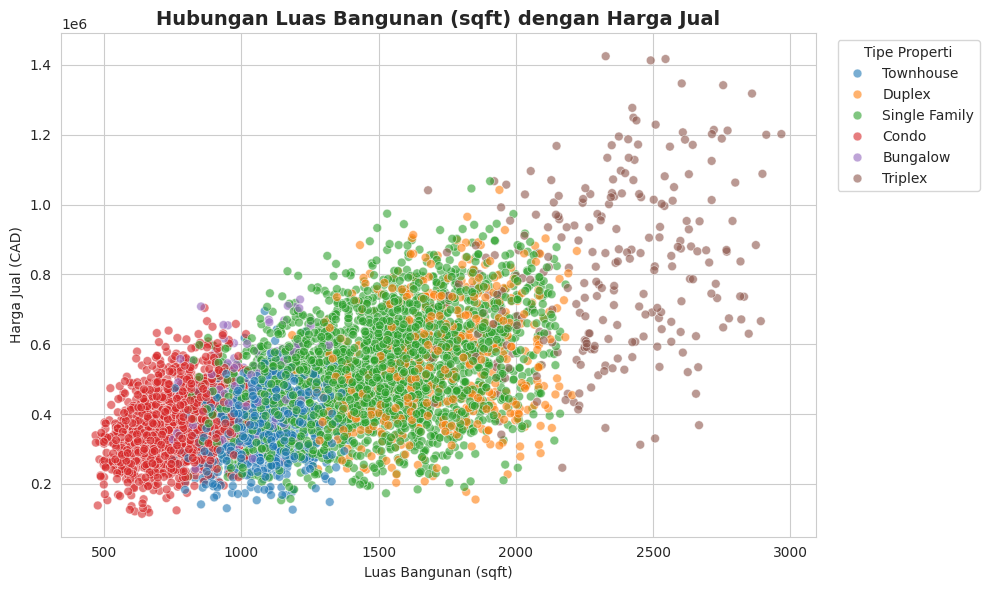

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x="living_area_sqft", y="sale_price",
                hue="property_type", alpha=0.6, palette="tab10", s=40)
plt.title("Hubungan Luas Bangunan (sqft) dengan Harga Jual", fontsize=14, fontweight="bold")
plt.xlabel("Luas Bangunan (sqft)")
plt.ylabel("Harga Jual (CAD)")
plt.legend(title="Tipe Properti", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.savefig("scatter_area_price.png", dpi=150)
plt.show()

In [ ]:
corr_value = df["living_area_sqft"].corr(df["sale_price"])
print(f"Korelasi Pearson antara living_area_sqft dan sale_price: {corr_value:.3f}")

Korelasi Pearson antara living_area_sqft dan sale_price: 0.632


### 4. Heatmap — Korelasi Antar Fitur Numerik

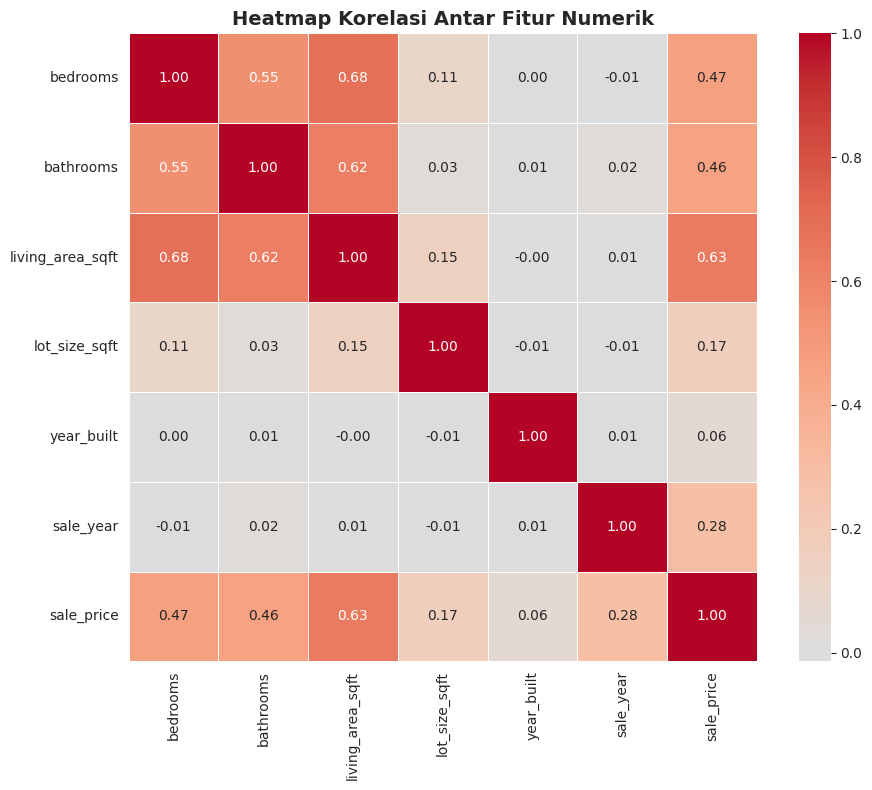

In [ ]:
plt.figure(figsize=(10, 8))
corr_matrix = df[["bedrooms", "bathrooms", "living_area_sqft", "lot_size_sqft",
                   "year_built", "sale_year", "sale_price"]].corr()
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            linewidths=0.5, square=True)
plt.title("Heatmap Korelasi Antar Fitur Numerik", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("heatmap_corr.png", dpi=150)
plt.show()